In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = '/content/drive/MyDrive/ObesityDataSet.csv'
df = pd.read_csv(path)

In [ ]:
# Beberapa baris pertama
print(df.head())

# Informasi umum
print(df.info())

# Statistik deskriptif
print(df.describe(include='all'))

  Age  Gender Height Weight        CALC FAVC FCVC NCP  SCC SMOKE CH2O  \
0  21  Female   1.62     64          no   no    2   3   no    no    2   
1  21  Female   1.52     56   Sometimes   no    3   3  yes   yes    3   
2  23    Male    1.8     77  Frequently   no    2   3   no    no    2   
3  27    Male    1.8     87  Frequently   no    3   3   no    no    2   
4  22    Male   1.78   89.8   Sometimes   no    2   1   no    no    2   

  family_history_with_overweight FAF TUE       CAEC                 MTRANS  \
0                            yes   0   1  Sometimes  Public_Transportation   
1                            yes   3   0  Sometimes  Public_Transportation   
2                            yes   2   1  Sometimes  Public_Transportation   
3                             no   2   0  Sometimes                Walking   
4                             no   0   0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Weight  
1        Normal_Weight  
2        Normal_W

In [ ]:
# Cek missing values
print(df.isnull().sum())

# Cek data duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")

# Cek jumlah nilai unik per kolom
print(df.nunique())

Age                               14
Gender                             9
Height                            12
Weight                            11
CALC                               5
FAVC                              11
FCVC                               8
NCP                               12
SCC                               10
SMOKE                              5
CH2O                               6
family_history_with_overweight    13
FAF                                8
TUE                                9
CAEC                              11
MTRANS                             6
NObeyesdad                         0
dtype: int64
Jumlah duplikat: 18
Age                               1394
Gender                               3
Height                            1562
Weight                            1518
CALC                                 5
FAVC                                 3
FCVC                               808
NCP                                637
SCC                       

In [ ]:
import numpy as np

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
df = df.drop_duplicates()

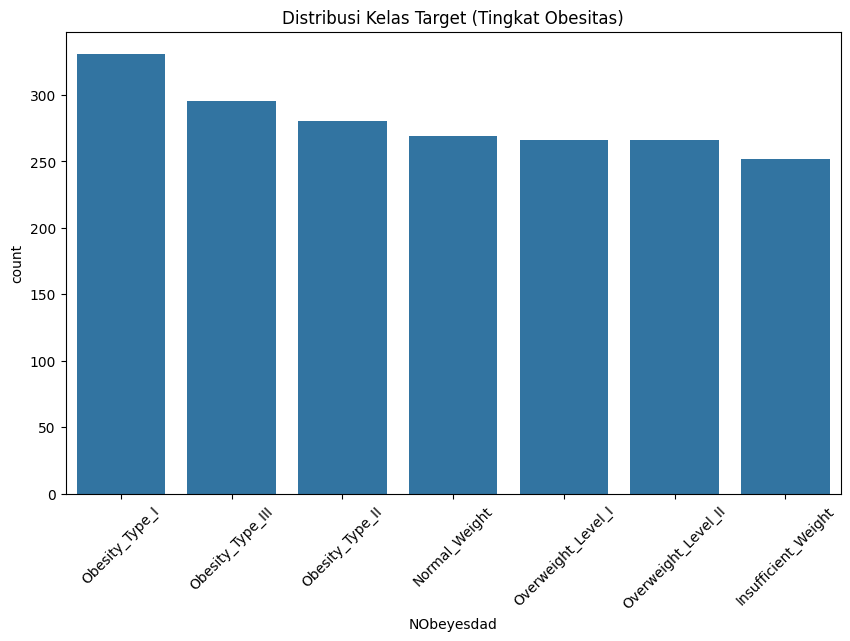

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribusi Kelas Target (Tingkat Obesitas)')
plt.show()

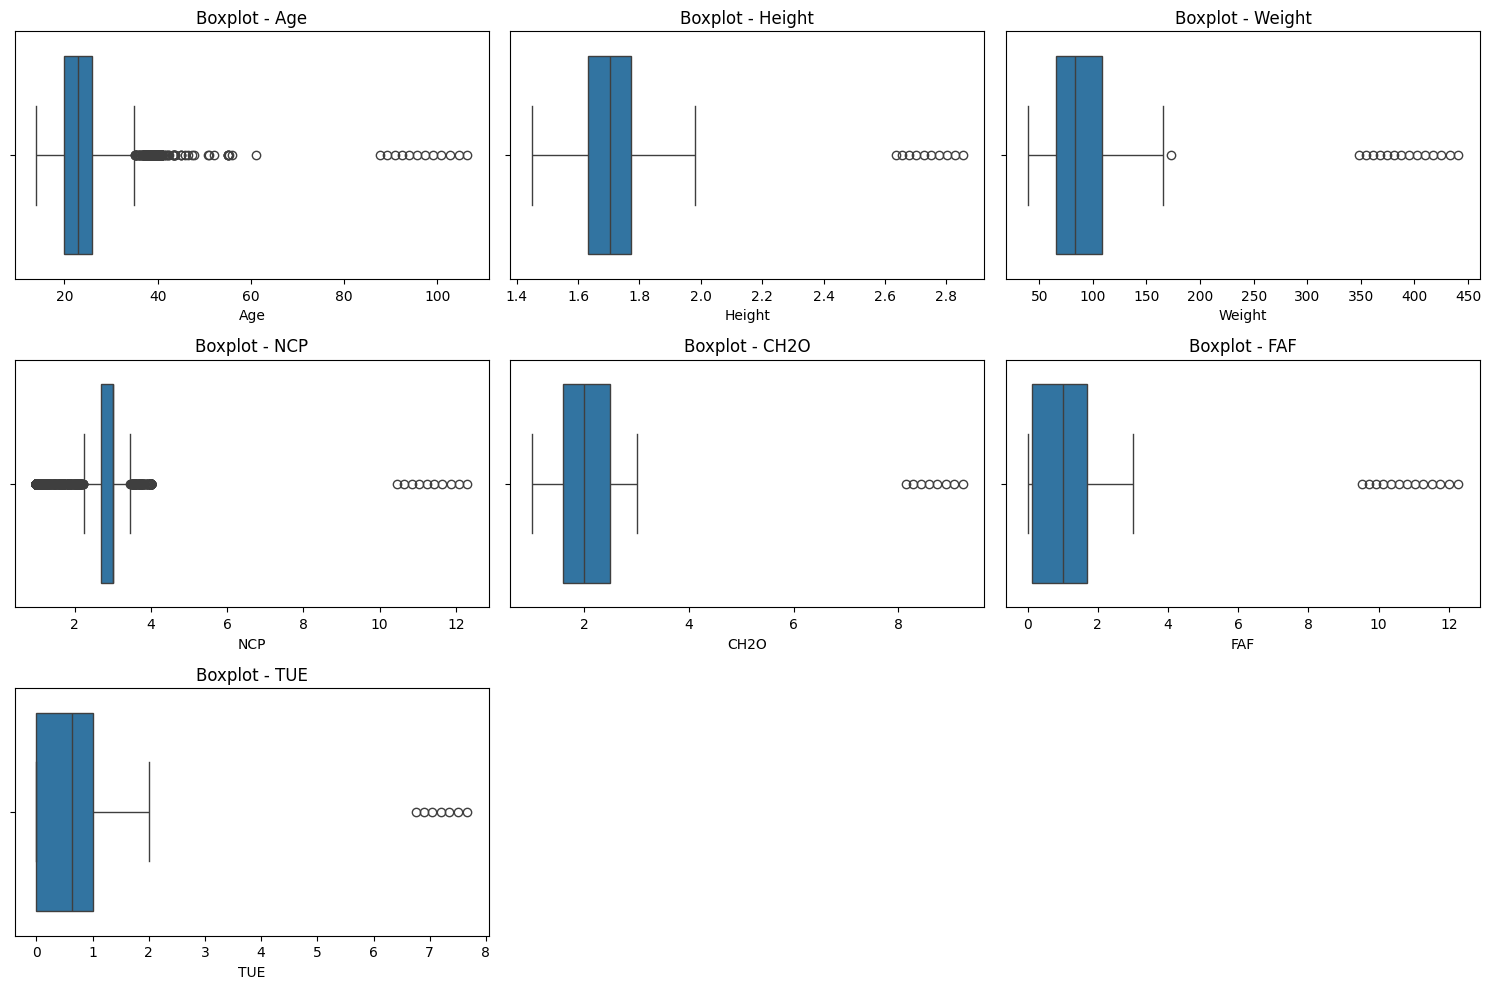

In [ ]:
num_cols = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
plt.tight_layout()
plt.show()

df = df.dropna(subset=num_cols)

In [ ]:
import numpy as np
import pandas as pd

# Konversi kolom numerik yang masih object
numerik_cols = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in numerik_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # ubah selain angka jadi NaN

# Hapus baris yang mengandung NaN di kolom numerik
df = df.dropna(subset=numerik_cols)

In [ ]:
print(df.dtypes[numerik_cols])

Age       float64
Height    float64
Weight    float64
NCP       float64
CH2O      float64
FAF       float64
TUE       float64
dtype: object


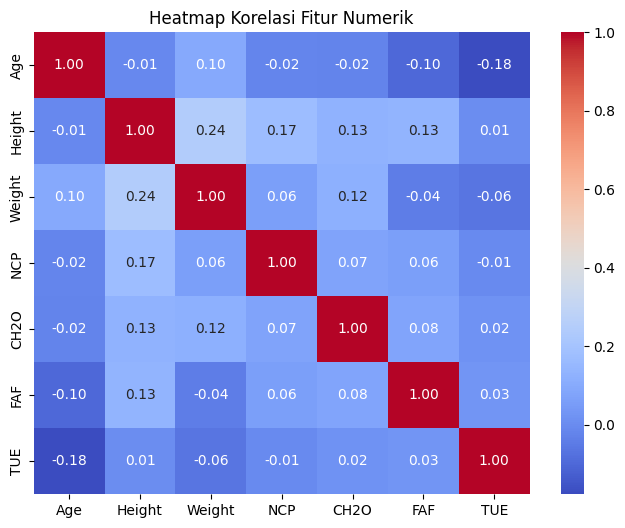

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[numerik_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

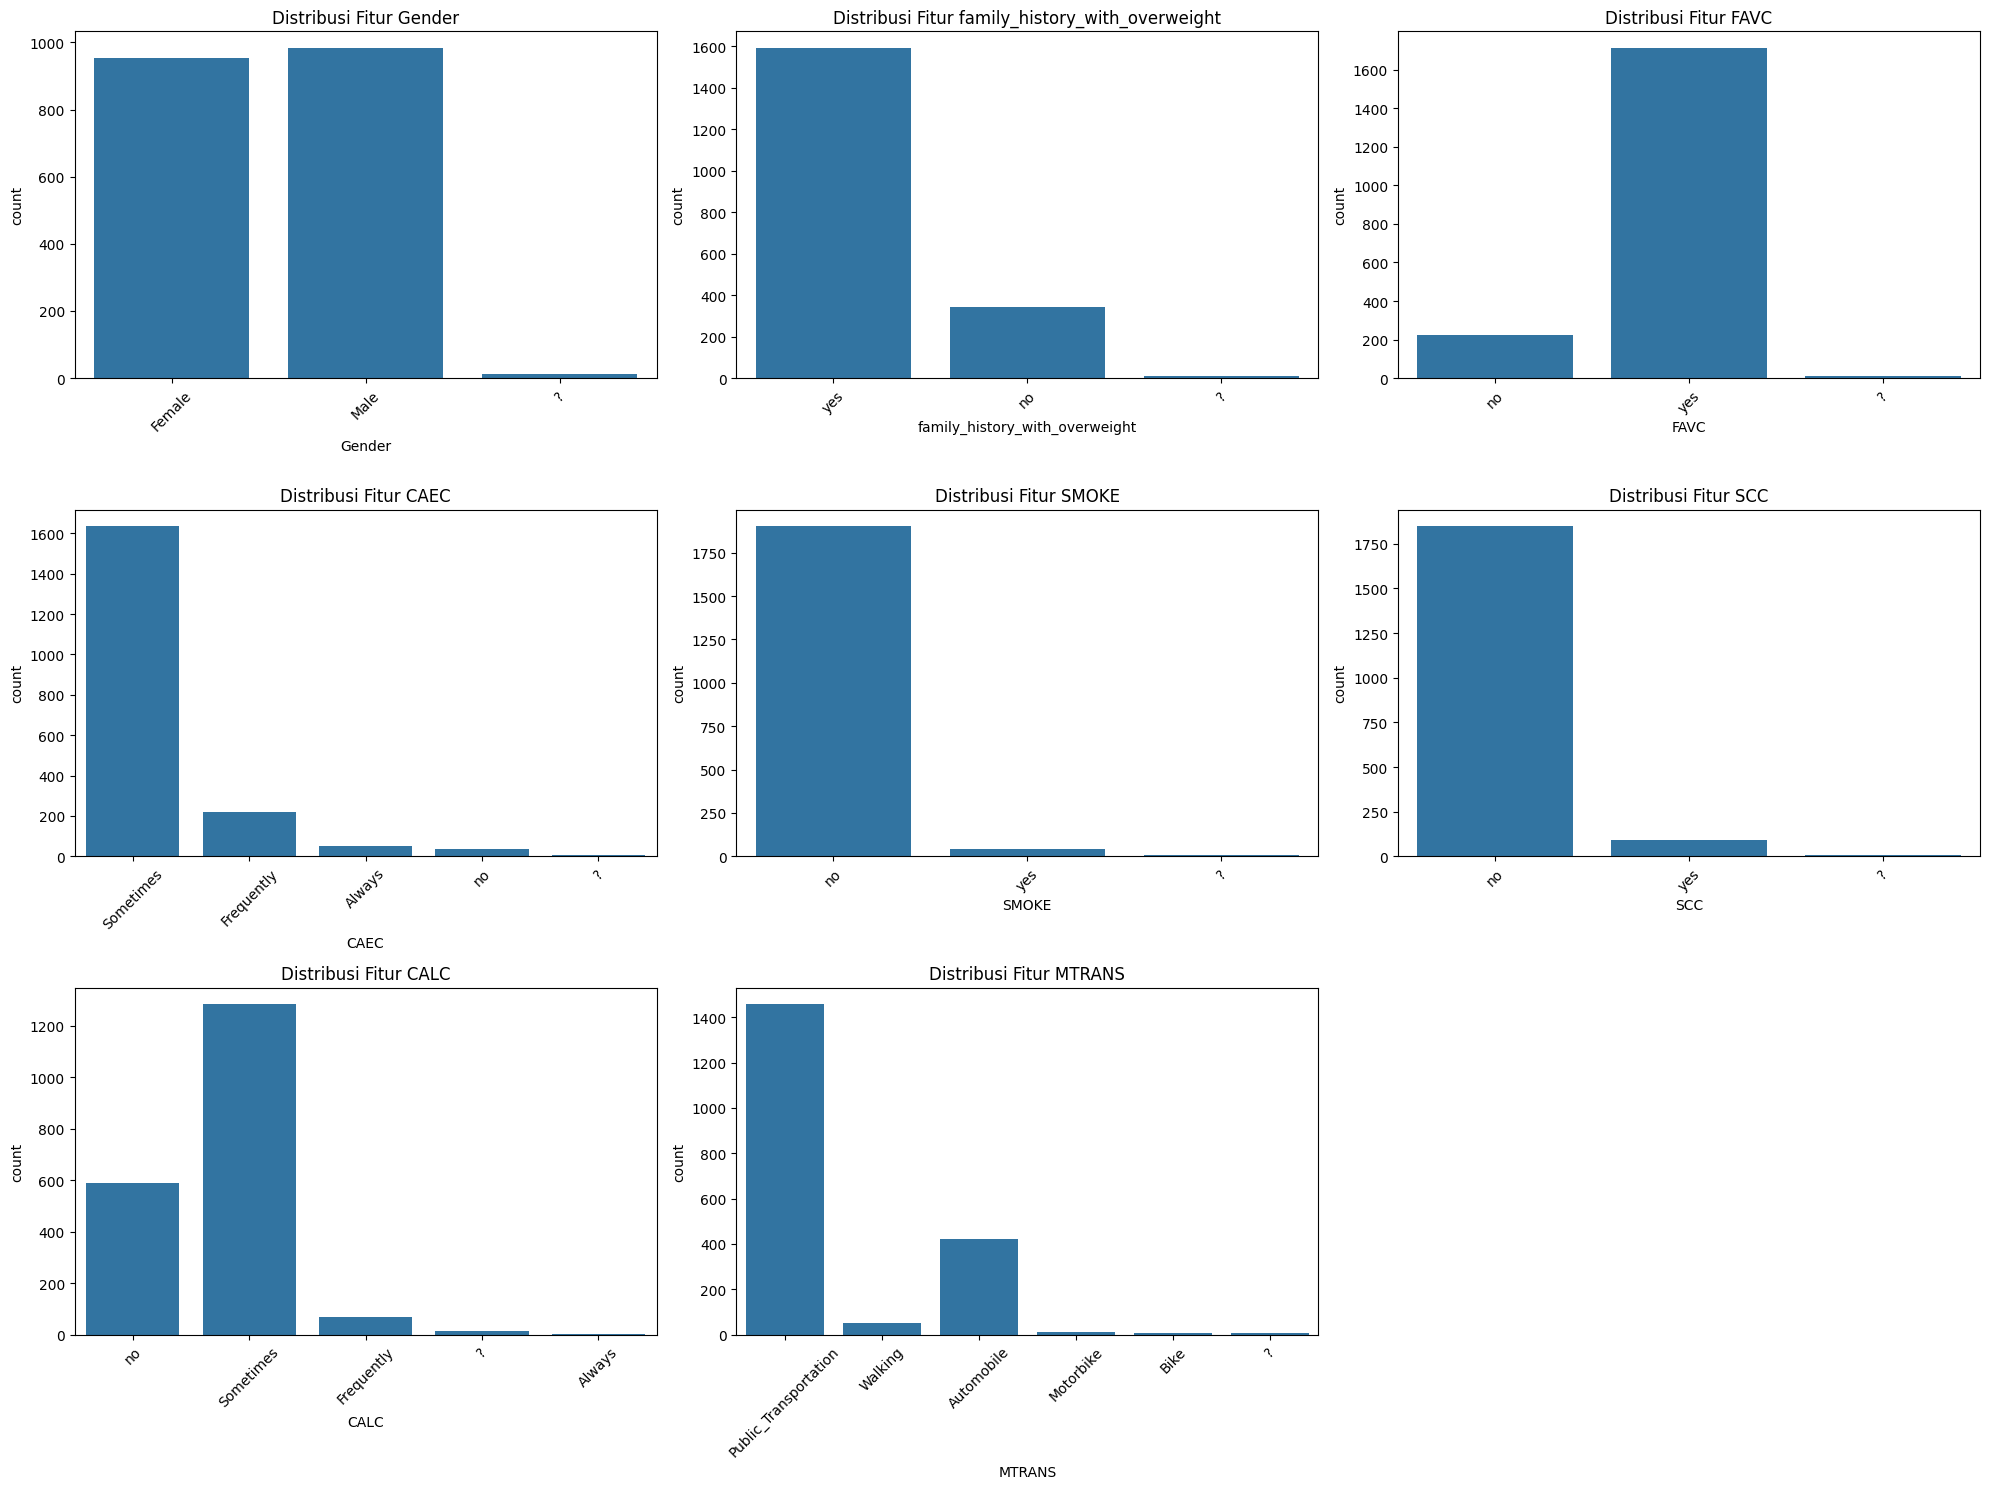

In [ ]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']

plt.figure(figsize=(20,15))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribusi Fitur {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Informasi Umum Dataset
Dataset berisi 2111 entri dan 17 fitur, namun setelah duplikat dihapus, jumlah entri berkurang menjadi 2086 (jumlah ini tergantung jumlah duplikat aktual).

Data bersumber dari tiga negara: Meksiko, Peru, dan Kolombia, dan berisi informasi pola makan, gaya hidup, serta kondisi fisik individu.Target klasifikasi adalah NObeyesdad, yaitu tingkat obesitas yang terbagi menjadi 7 kelas.

Distribusi Kelas (Target)
Terdapat ketidakseimbangan distribusi pada label target.
Mayoritas data berada di kategori “Normal Weight” dan “Obesity Type I”, sementara kategori seperti “Insufficient Weight” dan “Obesity Type III” lebih jarang.

Cek Data
Missing values: Tidak ditemukan nilai kosong secara eksplisit, namun nilai seperti '?' perlu dibersihkan terlebih dahulu agar tidak menyebabkan error saat analisis numerik.
Duplikat: Telah ditemukan dan berhasil dihapus.
Outlier: Beberapa fitur numerik seperti Weight, Height, dan FAF menunjukkan keberadaan outlier berdasarkan boxplot.
Fitur kategorikal memiliki distribusi yang cukup merata, seperti Gender, FAVC, MTRANS, dll.

Korelasi Fitur
Korelasi antar fitur numerik relatif lemah hingga sedang, yang berarti tidak ada multikolinearitas ekstrem, namun tetap ada beberapa hubungan seperti:
Height dan Weight
FAF dan CH2O



In [4]:
import pandas as pd
import numpy as np


# Bersihkan nilai error — ganti '?' menjadi NaN
df.replace('?', np.nan, inplace=True)

# Cek dan tangani missing values
df = df.dropna()  # Drop rows with missing data

# Hapus duplikat jika masih ada
df = df.drop_duplicates()

# Konversi kolom numerik yang masih object
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Tangani outlier dengan IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]


In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode semua kolom kategorikal otomatis
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


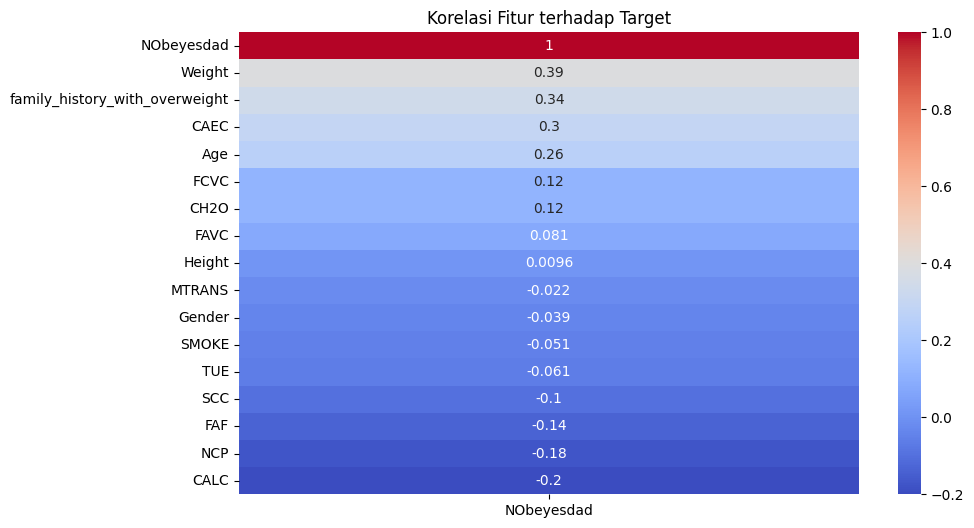

In [6]:
# Cek korelasi terhadap target
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[['NObeyesdad']].sort_values(by='NObeyesdad', ascending=False), annot=True, cmap='coolwarm')
plt.title("Korelasi Fitur terhadap Target")
plt.show()


In [7]:
from imblearn.over_sampling import SMOTE

# Pisahkan fitur dan target
X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Gabungkan kembali jika perlu untuk modeling atau analisis lebih lanjut
df_resampled = pd.concat([pd.DataFrame(X_res, columns=X.columns), pd.DataFrame(y_res, columns=['NObeyesdad'])], axis=1)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# Konversi kembali ke DataFrame jika diperlukan
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


Kesimpulan Preprocessing
Dari tahapan preprocessing di atas, diperoleh beberapa hal penting:

Semua nilai error (?) dan missing values berhasil dibersihkan.

Duplikasi dan outlier berhasil dihapus untuk menjaga validitas analisis.

Seluruh fitur kategorikal dikonversi ke bentuk numerik.

Data target (NObeyesdad) yang tidak seimbang telah diseimbangkan menggunakan teknik SMOTE.

Seluruh fitur numerik telah distandarisasi dengan StandardScaler agar model bekerja optimal.

Semua fitur digunakan untuk tahap modeling, namun dapat dievaluasi kembali saat analisis feature importance.